<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/SistemasInteligentes/SistemasInteligentes_ClassificadorCavalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# dataset de cavalos kaggle
import kagglehub
# executa função do dataset e python baixa arquivos e salva cominho da pasta
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")
# caminho onde os arquivos foram salvos
print("Pasta que as imagens estão guardadas:", path)

100%|██████████| 82.0M/82.0M [00:00<00:00, 162MB/s]

Extracting files...


Pasta que as imagens estão guardadas: /root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27


In [2]:
# dataset de pessoas kaggle
# usando pandas para selecionar alearotiamente uma quantidade de imagens do dataset
import kagglehub

path = kagglehub.dataset_download("ahmadahmadzada/images2000")
print("Pasta que as imagens estão guardadas:", path)


100%|██████████| 85.9M/85.9M [00:00<00:00, 195MB/s]

Extracting files...


Pasta que as imagens estão guardadas: /root/.cache/kagglehub/datasets/ahmadahmadzada/images2000/versions/1


In [3]:
import os
import shutil
import random
from google.colab import drive

drive.mount('/content/drive')

# Definição de caminhos
diretorio_dataset_cavalos = "/root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27"
diretorio_dataset_nao_cavalos = "/root/.cache/kagglehub/datasets/ahmadahmadzada/images2000/versions/1"
diretorio_destinoDrive = "/content/drive/MyDrive/Trabalho_SistemasInteligentes"

# Pasta temporária para organizar antes de zipar
pasta_temp = "/content/temp_dataset"
os.makedirs(pasta_temp, exist_ok=True)

# Função para selecionar e preparar dados
def preparar_dados():
    caminhos_cavalos = [os.path.join(raiz, arq) for raiz, _, arqs in os.walk(diretorio_dataset_cavalos) for arq in arqs if arq.lower().endswith(('.png', '.jpg', '.jpeg'))]
    caminhos_nao_cavalos_full = [os.path.join(raiz, arq) for raiz, _, arqs in os.walk(diretorio_dataset_nao_cavalos) for arq in arqs if arq.lower().endswith(('.png', '.jpg', '.jpeg'))]

    qtd_ideal = min(len(cavalos_sel := caminhos_cavalos[:len(caminhos_cavalos)]), len(caminhos_nao_cavalos_full))
    caminhos_nao_cavalos_sel = random.sample(caminhos_nao_cavalos_full, qtd_ideal)

    return caminhos_cavalos[:qtd_ideal], caminhos_nao_cavalos_sel

cavalos, nao_cavalos = preparar_dados()

# Organizar em pastas temporárias e renomear
def organizar(lista, pasta_nome):
    destino = os.path.join(pasta_temp, pasta_nome)
    os.makedirs(destino, exist_ok=True)
    for i, origem in enumerate(lista, 1):
        ext = os.path.splitext(origem)[1]
        shutil.copy2(origem, os.path.join(destino, f"{i}{ext}"))
    return destino

dir_cav = organizar(cavalos, "cavalos")
dir_nao = organizar(nao_cavalos, "nao_cavalos")

# Compactar e mover para o Drive
print("Compactando e enviando para o Drive...")
shutil.make_archive(os.path.join(diretorio_destinoDrive, "cavalos"), 'zip', dir_cav)
shutil.make_archive(os.path.join(diretorio_destinoDrive, "nao_cavalos"), 'zip', dir_nao)

# Limpeza
shutil.rmtree(pasta_temp)

print("Processo finalizado com sucesso. Arquivos .zip criados no seu Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Compactando e enviando para o Drive...
Processo finalizado com sucesso. Arquivos .zip criados no seu Drive.


# Para classificar se é cavalo ou não:
- A classificação binária SEMPRE exigirá o 'conhecimento' do que é e do que não é o seu objetivo.
- Como um classificador de tarefa de aprendizado supervisionado, o modelo, obrigatoriamente, deve diferenciar o que é a classe A e o que NÃO é a classe A.
- Todos os filtros de extração de características devem ser aplicados em ambas as classes, para que o modelo tenha exemplos positivos e negativos das características extraídas (bordas, texturas, silhueta) que caracterizam um cavalo e o que o diferencia de um ser humano ou paisagem.

# Pré-processamento e Extração de Característica 1
### 1) Padronização e Intensidade Luminosa (Tons de Cinza)
Imagens brutas não podem ser entregues diretamente aos classificadores, pois os algoritmos precisam que elas sejam transformadas em matrizes numéricas padronizadas para conseguirem calcular a distância geométrica entre os pixels.

* **O Pré-processamento Técnico:** Consiste em redimensionar a imagem para $64 \times 64$ pixels, mudar o tipo de dado (geralmente para `float32`) e, no final de tudo, achatar a matriz (aplicar o `flatten`) para transformá-la em um vetor linear. Isso garante que todas as entradas do dataset tenham exatamente o mesmo tamanho e formato exigidos pelo classificador.

* **Característica 1 (Tons de Cinza):** A conversão da imagem colorida para tons de cinza cumpre um papel duplo. Ela funciona como pré-processamento (porque a maioria dos filtros matemáticos das próximas etapas exige uma imagem de canal único para funcionar), mas também é a primeira extração de característica. Ela extrai o **Mapa de Intensidade Luminosa**, entregando ao classificador os valores puros de brilho e iluminação do corpo do animal e do cenário.

**Fluxo Prático:** Todos os filtros seguintes (Sobel, Laplaciano, Gaussiano, Mediana e Canny) são aplicados em cima desta imagem já convertida para cinza e redimensionada para $64 \times 64$. Isso garante que todas as 7 matrizes de características nasçam com o mesmo tamanho físico antes de serem achatadas para um algoritmo de classificação.

FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento


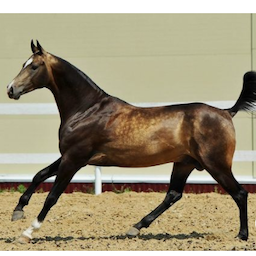

-------------------------------------------------------
Formato original da imagem (Estrutura física): (256, 256, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


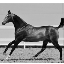

-------------------------------------------------------
EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:
Visualização dos 10 primeiros pixels no vetor:
 [255. 255. 255. 255. 255. 255. 255. 255. 255. 255.]
-------------------------------------------------------
--- TESTE DE DIAGNÓSTICO: Iniciando processamento da classe NÃO CAVALO ---
FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento


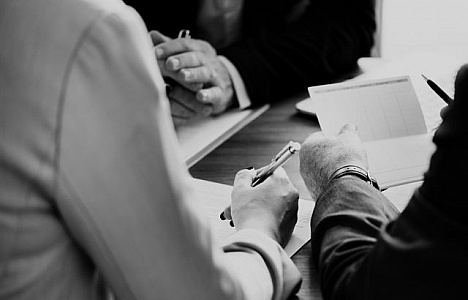

-------------------------------------------------------
MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA
Formato original da imagem (Estrutura física): (300, 468, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


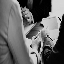

-------------------------------------------------------
COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :
Visualização dos 10 primeiros pixels no vetor:
 [ 88.  99. 107. 111. 117. 121. 121. 129. 133. 140.]
-------------------------------------------------------


In [7]:
import numpy as np
import cv2 as cv
import os
from google.colab.patches import cv2_imshow

# MANTER ESTAS VARIÁVEIS ATUALIZADAS PARA O LOCAL:
diretorio_destinoDrive_cavalos = "/content/cavalos"
diretorio_destinoDrive_nao_cavalos = "/content/nao_cavalos"

# Listar arquivos que estão dentro da pasta
arquivos_cavalos = os.listdir(diretorio_destinoDrive_cavalos)
arquivos_nao_cavalos = os.listdir(diretorio_destinoDrive_nao_cavalos)

# Listas para armazenar os resultados
resultadoVetores_cavalos = []
resultadoVetores_nao_cavalos = []

# Lista para guardar todas as imagems apos o pré-processamento, extração de caracteristica 1
imagensCom_Caracteristica1_cavalos = []
imagensCom_Caracteristica1_nao_cavalos = []

# EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
for nome_arquivo in arquivos_cavalos:
    # Cria o caminho completo para cada imagem (ex: /.../datasetCavalos/1.jpg)
    caminhoCompleto = os.path.join(diretorio_destinoDrive_cavalos, nome_arquivo)
    # Carrega a imagem atual
    img_original_cavalo = cv.imread(caminhoCompleto)

    # --- LOG DE SEGURANÇA ---
    if img_original_cavalo is None:
        print(f"AVISO: Pulando arquivo corrompido em CAVALOS: {nome_arquivo}")
        continue

    # converter imgs para tons de cinza
    caracteristica_1_cavalo = cv.cvtColor(img_original_cavalo, cv.COLOR_BGR2GRAY)

    # REPRESENTAÇÃO DA MESMA IMAGEM - PRIMEIRA: IMGREDIMENCIONADA - 64,64
    # REPRESENTACAO DA MESMA IMAGEM  - SEGUNDA: VETORCARACTERISTICAS - 4096 MESMA INFO MAS ACHATADA

    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_cavalos = cv.resize(caracteristica_1_cavalo, tamanhoPadrao)

    # Apenas para ver o logs:
    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_cavalo = imgRedimensionada_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_cavalo.astype(np.float32)
    resultadoVetores_cavalos.append(vetorCaracteristicas)

    # armazenando todas as imagens com caracteristica 1 já extraida
    imagensCom_Caracteristica1_cavalos.append(imgRedimensionada_cavalos)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_cavalos_np = np.array(resultadoVetores_cavalos)

print("FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_cavalo)
print("-" * 55)

print("Formato original da imagem (Estrutura física):", img_original_cavalo.shape)
print("Tipo de dado original da imagem na memória:", img_original_cavalo.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_cavalos_np.dtype)

print("Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_cavalos)
print("-" * 55)

print("EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
print("--- TESTE DE DIAGNÓSTICO: Iniciando processamento da classe NÃO CAVALO ---")
voltas = 0
for nome_arquivo in arquivos_nao_cavalos:
    voltas += 1

    # Cria o caminho completo para cada imagem
    caminhoCompleto = os.path.join(diretorio_destinoDrive_nao_cavalos, nome_arquivo)

    # Carrega a imagem atual
    img_original_nao_cavalos = cv.imread(caminhoCompleto)

    # --- LOG DE SEGURANÇA ---
    if img_original_nao_cavalos is None:
        print(f"AVISO: Pulando arquivo corrompido em NÃO CAVALOS (volta {voltas}): {nome_arquivo}")
        continue

    # converter imgs para tons de cinza
    caracteristica_1_nao_cavalos = cv.cvtColor(img_original_nao_cavalos, cv.COLOR_BGR2GRAY)
    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_nao_cavalos = cv.resize(caracteristica_1_nao_cavalos, tamanhoPadrao)

    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_nao_cavalos = imgRedimensionada_nao_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_nao_cavalos.astype(np.float32)

    resultadoVetores_nao_cavalos.append(vetorCaracteristicas)
    imagensCom_Caracteristica1_nao_cavalos.append(imgRedimensionada_nao_cavalos)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_nao_cavalos_np = np.array(resultadoVetores_nao_cavalos)

print("FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_nao_cavalos)
print("-" * 55)

print("MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA")
print("Formato original da imagem (Estrutura física):", img_original_nao_cavalos.shape)
print("Tipo de dado original da imagem na memória:", img_original_nao_cavalos.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_nao_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_nao_cavalos_np.dtype)
print("Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_nao_cavalos)
print("-" * 55)

print("COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

# Extração de Características:
### 2) Bordas e Gradientes

Esta célula executa a extração de características através da aplicação de filtros matemáticos independentes sobre a matriz de $64 \times 64$ em tons de cinza. A partir de uma única imagem de entrada, o fluxo gera **3 matrizes de características totalmente distintas** para os algoritmos de classificação:

1. **Sobel X:** Destaca as **bordas verticais** (percorre o eixo X e captura linhas verticais, como as pernas do animal).
2. **Sobel Y:** Destaca as **bordas horizontais** (percorre o eixo Y e captura linhas horizontais, como o dorso).
3. **Laplaciano:** Mapeia o **relevo geral**, capturando todas as direções de contorno simultaneamente.

**Nota Matemática de Implementação:** As transições de cor geram valores positivos e negativos na memória. Por isso, o código utiliza a profundidade `cv.CV_64F` para preservar os gradientes negativos, aplica o valor absoluto com `np.absolute()` e converte o tipo final para `float32`, formato padrão exigido para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho do Kernel (`ksize`), Direção da Derivada (`xorder`/`yorder`) e a variação estável do Filtro de Scharr.

Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)


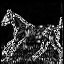

-------------------------------------------------------
Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)


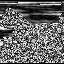

-------------------------------------------------------
Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)


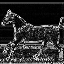

-------------------------------------------------------
Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)


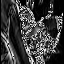

-------------------------------------------------------
Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)


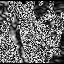

-------------------------------------------------------
Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)


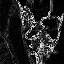

-------------------------------------------------------


In [15]:
# EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
resultadoVetores_caracteristica2_cavalos = []
resultadoVetores_caracteristica3_cavalos = []
resultadoVetores_caracteristica4_cavalos = []

for imgRedimensionada_cavalos in imagensCom_Caracteristica1_cavalos:
    # Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
    sobel_x_float = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 1, 0, ksize=3)
    # tranforma negativos em positivos
    sobel_x_absoluto_cavalo = np.absolute(sobel_x_float)
    # tipo para o uso do knn
    caracteristica_2_cavalo = sobel_x_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica2_cavalos.append(caracteristica_2_cavalo.flatten())

    # Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
    sobel_y_float_cavalo = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 0, 1, ksize=5)
    sobel_y_absoluto_cavalo = np.absolute(sobel_y_float_cavalo)
    caracteristica_3_cavalo = sobel_y_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica3_cavalos.append(caracteristica_3_cavalo.flatten())

    # Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
    laplacian_float_cavalo = cv.Laplacian(imgRedimensionada_cavalos, cv.CV_64F)
    # tranforma negativos em positivos
    laplacian_absoluto_cavalo = np.absolute(laplacian_float_cavalo)
    # tipo para o uso do knn
    caracteristica_4_cavalo = laplacian_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica4_cavalos.append(caracteristica_4_cavalo.flatten())

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica2_cavalos_np = np.array(resultadoVetores_caracteristica2_cavalos)
resultadoVetores_caracteristica3_cavalos_np = np.array(resultadoVetores_caracteristica3_cavalos)
resultadoVetores_caracteristica4_cavalos_np = np.array(resultadoVetores_caracteristica4_cavalos)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_cavalo = np.uint8(sobel_x_absoluto_cavalo)
imagem_visual_y_cavalo = np.uint8(sobel_y_absoluto_cavalo)
imagem_visual_lap_cavalo = np.uint8(laplacian_absoluto_cavalo)

print("Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_cavalo)
print("-" * 55)
print("Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_cavalo)
print("-" * 55)
print("Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_cavalo)
print("-" * 55)

# EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
resultadoVetores_caracteristica2_nao_cavalos = []
resultadoVetores_caracteristica3_nao_cavalos = []
resultadoVetores_caracteristica4_nao_cavalos = []

for imgRedimensionada_nao_cavalos in imagensCom_Caracteristica1_nao_cavalos:
    # Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
    sobel_x_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 1, 0, ksize=3)
    # tranforma negativos em positivos
    sobel_x_absoluto_nao_cavalos = np.absolute(sobel_x_float_nao_cavalos)
    # tipo para o uso do knn
    caracteristica_2_nao_cavalos = sobel_x_absoluto_nao_cavalos.astype(np.float32)
    # conversao numPy
    resultadoVetores_caracteristica2_nao_cavalos.append(caracteristica_2_nao_cavalos.flatten())

    # Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
    sobel_y_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 0, 1, ksize=5)
    sobel_y_absoluto_nao_cavalos = np.absolute(sobel_y_float_nao_cavalos)
    caracteristica_3_nao_cavalos = sobel_y_absoluto_nao_cavalos.astype(np.float32)
    resultadoVetores_caracteristica3_nao_cavalos.append(caracteristica_3_nao_cavalos.flatten())

    # Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
    laplacian_float_nao_cavalos = cv.Laplacian(imgRedimensionada_nao_cavalos, cv.CV_64F)
    # tranforma negativos em positivos
    laplacian_absoluto_nao_cavalos = np.absolute(laplacian_float_nao_cavalos)
    # tipo para o uso do knn
    caracteristica_4_nao_cavalos = laplacian_absoluto_nao_cavalos.astype(np.float32)
    resultadoVetores_caracteristica4_nao_cavalos.append(caracteristica_4_nao_cavalos.flatten())

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica2_nao_cavalos_np = np.array(resultadoVetores_caracteristica2_nao_cavalos)
resultadoVetores_caracteristica3_nao_cavalos_np = np.array(resultadoVetores_caracteristica3_nao_cavalos)
resultadoVetores_caracteristica4_nao_cavalos_np = np.array(resultadoVetores_caracteristica4_nao_cavalos)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_nao_cavalos = np.uint8(sobel_x_absoluto_nao_cavalos)
imagem_visual_y_nao_cavalos = np.uint8(sobel_y_absoluto_nao_cavalos)
imagem_visual_lap_nao_cavalos = np.uint8(laplacian_absoluto_nao_cavalos)

print("Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_nao_cavalos)
print("-" * 55)

# Extração de Características:
### 3) Filtros de Textura, Frequência e Silhueta (Suavização e Geometria)

Esta célula executa a extração de características através da aplicação de filtros que simplificam a imagem e destacam o formato do animal. A partir da mesma imagem base ($64 \times 64$ pixels em tons de cinza), o fluxo gera mais **3 matrizes de características distintas** para os algoritmos de classificação:

1. **Desfoque Gaussiano:** Suaviza a imagem de forma homogênea. O filtro elimina detalhes irrelevantes de alta frequência (como texturas de pelos) e direciona o foco do classificador para o **tamanho, volume e postura macro** do corpo do cavalo.
2. **Filtro de Mediana:** Reduz ruídos isolados ao substituir o valor do pixel central pelo elemento mediano da vizinhança. O processo transforma superfícies texturizadas em blocos sólidos de intensidade, **sem borrar ou degradar o recorte das bordas**.
3. **Detector de Canny:** Converte a imagem em uma matriz binária (preto e branco puro). O algoritmo extingue todas as sombras e tons intermediários de cinza, isolando a **silhueta geométrica exata** do objeto.

**Nota Prática de Implementação:** O Gaussiano e a Mediana operam no rearranjo e ponderação dos pixels vizinhos para atenuar variações abruptas de textura. O Canny aplica um pipeline de limiarização por histerese para reter apenas as linhas de contorno principais. Ao final do processamento, ocorre a conversão de todas as matrizes para o tipo `float32`, formato padrão necessário para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho da matriz de varredura (`Kernel`), desvio padrão do borrão (`SigmaX`) e os limites de corte de linhas do Canny (`Limiares de Histerese`).

Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)


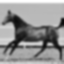

-------------------------------------------------------
Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


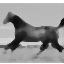

-------------------------------------------------------
Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


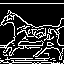

-------------------------------------------------------
Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)


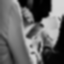

-------------------------------------------------------
Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


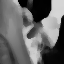

-------------------------------------------------------
Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


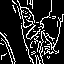

-------------------------------------------------------


In [16]:
#EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS

# Listas para armazenar os resultados
resultadoVetores_caracteristica5_cavalos = []
resultadoVetores_caracteristica6_cavalos = []
resultadoVetores_caracteristica7_cavalos = []

for imgRedimensionada_cavalos in imagensCom_Caracteristica1_cavalos:

    # Desfoque Gaussiano
    gaussian_float_cavalo = cv.GaussianBlur(imgRedimensionada_cavalos, (5, 5), 0)
    # tranforma negativos em positivos
    caracteristica_5_cavalo = gaussian_float_cavalo.astype(np.float32)
    # transformar imagem em vetor para o k-NN
    vetorCaracteristica5 = caracteristica_5_cavalo.flatten()
    resultadoVetores_caracteristica5_cavalos.append(vetorCaracteristica5)

    # Filtro de Mediana
    median_float_cavalo = cv.medianBlur(imgRedimensionada_cavalos, 5)
    caracteristica_6_cavalo = median_float_cavalo.astype(np.float32)
    vetorCaracteristica6 = caracteristica_6_cavalo.flatten()
    resultadoVetores_caracteristica6_cavalos.append(vetorCaracteristica6)

    # Canny
    canny_float_cavalo = cv.Canny(imgRedimensionada_cavalos, 100, 200)
    caracteristica_7_cavalo = canny_float_cavalo.astype(np.float32)
    vetorCaracteristica7 = caracteristica_7_cavalo.flatten()
    resultadoVetores_caracteristica7_cavalos.append(vetorCaracteristica7)


# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica5_cavalos_np = np.array(resultadoVetores_caracteristica5_cavalos)
resultadoVetores_caracteristica6_cavalos_np = np.array(resultadoVetores_caracteristica6_cavalos)
resultadoVetores_caracteristica7_cavalos_np = np.array(resultadoVetores_caracteristica7_cavalos)

print("Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_cavalo = np.uint8(caracteristica_5_cavalo)
cv2_imshow(imagem_visual_gauss_cavalo)
print("-" * 55)

print("Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_cavalo = np.uint8(caracteristica_6_cavalo)
cv2_imshow(imagem_visual_median_cavalo)
print("-" * 55)

print("Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_cavalo = np.uint8(caracteristica_7_cavalo)
cv2_imshow(imagem_visual_canny_cavalo)
print("-" * 55)


#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
# Listas para armazenar os resultados
resultadoVetores_caracteristica5_nao_cavalos = []
resultadoVetores_caracteristica6_nao_cavalos = []
resultadoVetores_caracteristica7_nao_cavalos = []

for imgRedimensionada_nao_cavalos in imagensCom_Caracteristica1_nao_cavalos:

    # Desfoque  Gaussiano
    gaussian_float_nao_cavalos = cv.GaussianBlur(imgRedimensionada_nao_cavalos, (5, 5), 0)
    caracteristica_5_nao_cavalos = gaussian_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica5 = caracteristica_5_nao_cavalos.flatten()
    resultadoVetores_caracteristica5_nao_cavalos.append(vetorCaracteristica5)

    # Mediana gaussian_float
    median_float_nao_cavalos = cv.medianBlur(imgRedimensionada_nao_cavalos, 5)
    caracteristica_6_nao_cavalos = median_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica6 = caracteristica_6_nao_cavalos.flatten()
    resultadoVetores_caracteristica6_nao_cavalos.append(vetorCaracteristica6)

    # Canny
    canny_float_nao_cavalos = cv.Canny(imgRedimensionada_nao_cavalos, 100, 200)
    caracteristica_7_nao_cavalos = canny_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica7 = caracteristica_7_nao_cavalos.flatten()
    resultadoVetores_caracteristica7_nao_cavalos.append(vetorCaracteristica7)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica5_nao_cavalos_np = np.array(resultadoVetores_caracteristica5_nao_cavalos)
resultadoVetores_caracteristica6_nao_cavalos_np = np.array(resultadoVetores_caracteristica6_nao_cavalos)
resultadoVetores_caracteristica7_nao_cavalos_np = np.array(resultadoVetores_caracteristica7_nao_cavalos)

print("Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_nao_cavalos = np.uint8(caracteristica_5_nao_cavalos)
cv2_imshow(imagem_visual_gauss_nao_cavalos)
print("-" * 55)

print("Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_nao_cavalos = np.uint8(caracteristica_6_nao_cavalos)
cv2_imshow(imagem_visual_median_nao_cavalos)
print("-" * 55)

print("Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_nao_cavalos = np.uint8(caracteristica_7_nao_cavalos)
cv2_imshow(imagem_visual_canny_nao_cavalos)
print("-" * 55)

# AGRUPAMENTO (MATRIZ DE FEATURES)
## `np.concatenate()`

### É a função central para a consolidação de matrizes multidimensionais (`ndarrays`) no ecossistema NumPy. Essencial para o processamento e análise de dados, ele permite unir uma sequência de matrizes de forma rápida e eficiente em termos de memória.

**Regras de Ouro para a Concatenação:**
* **Estrutura Rígida:** Todos os elementos da tupla devem ser obrigatoriamente `Arrays NumPy` estruturados.
* **Compatibilidade de Shapes:** Os arrays precisam ter formatos compatíveis. Eles devem possuir o mesmo tamanho em todas as dimensões, exceto na dimensão em que a concatenação será realizada.
* **Dimensionalidade:** A união só pode ocorrer ao longo das dimensões existentes da matriz.

**Estrutura da Chamada:**
A função recebe dois argumentos principais: uma tupla contendo os arrays e o eixo (`axis`) de referência.

- np.concatenate((array1, array2, ...), axis=0)
    - axis=0: Empilha verticalmente (aumenta o número de linhas - ex: mais imagens)
    - axis=1: Empilha horizontalmente (aumenta o número de colunas - ex: mais atributos)

In [17]:

X_cavalos = np.concatenate(
    (resultadoVetores_cavalos_np, resultadoVetores_caracteristica2_cavalos_np,
     resultadoVetores_caracteristica3_cavalos_np, resultadoVetores_caracteristica4_cavalos_np,
     resultadoVetores_caracteristica5_cavalos_np, resultadoVetores_caracteristica6_cavalos_np,
     resultadoVetores_caracteristica7_cavalos_np), axis=1
)

X_nao_cavalos = np.concatenate(
    (resultadoVetores_nao_cavalos_np, resultadoVetores_caracteristica2_nao_cavalos_np,
     resultadoVetores_caracteristica3_nao_cavalos_np, resultadoVetores_caracteristica4_nao_cavalos_np,
     resultadoVetores_caracteristica5_nao_cavalos_np, resultadoVetores_caracteristica6_nao_cavalos_np,
     resultadoVetores_caracteristica7_nao_cavalos_np), axis=1
)

# PRINT DE CONFERÊNCIA
print("RELATÓRIO DE AGRUPAMENTO (MATRIZ DE FEATURES)")
print(f"Classe CAVALO: {X_cavalos.shape[0]} imagens | {X_cavalos.shape[1]} atributos totais")
print(f"Classe NÃO CAVALO: {X_nao_cavalos.shape[0]} imagens | {X_nao_cavalos.shape[1]} atributos totais")
print("-" * 55)

RELATÓRIO DE AGRUPAMENTO (MATRIZ DE FEATURES)
Classe CAVALO: 670 imagens | 28672 atributos totais
Classe NÃO CAVALO: 670 imagens | 28672 atributos totais
-------------------------------------------------------


In [ ]:
# Preparar dados para Treino

In [ ]:
# Salvar modelo - salvar aprendizado em arquivo xml